## 
Plots Comparisons
Alaska extRemes

'Loc & scale: time':  location.fun= ~ glost, scale.fun = ~glost <br>
'Loc: time':  location.fun= ~ glost <br>
'Loc & scale:time + Loc:PDO':  location.fun= ~ glost + PDO, scale.fun = ~glost <br>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
import geopandas as gpd

import matplotlib.colors as mcolors


In [2]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [3]:
import warnings
warnings.filterwarnings('ignore')

# READ EVGAM output FILES

In [11]:
yearb=1941
yeare=2025
lon_min = 235
lon_max = 293
lat_min = 25
lat_max = 50

dirin ='/data/ghervieux/TXx'


ds0 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_LocScaglost_extremes_1941_2025.nc')
rl1000 = ds0['rl100']
loc0 = ds0['location'] 
scale0 = ds0['scale'] 
shape0 = ds0['shape'] 
LocationDiff_q0 = ds0['LocationDiff_q']
ScaleDiff_q0 = ds0['ScaleDiff_q']
RLDiff_q0 = ds0['RLDiff_q']
RiskRatios_q0 = ds0['RiskRatios_q']
CRPS0 = ds0['CRPS']
DawSeb0 = ds0['DawSeb']
SE0 = ds0['SE']
KS_D0 = ds0['KS_D']
KS_pvalue0 = ds0['KS_pvalue']
CVM_D0 = ds0['CVM_D']
CVM_pvalue0 = ds0['CVM_pvalue']

ds1 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_Locglost_extremes_1941_2025.nc')
rl1001 = ds1['rl100']
loc1 = ds1['location'] 
scale1 = ds1['scale'] 
shape1 = ds1['shape'] 
LocationDiff_q1 = ds1['LocationDiff_q']
ScaleDiff_q1 = ds1['ScaleDiff_q']
RLDiff_q1 = ds1['RLDiff_q']
RiskRatios_q1 = ds1['RiskRatios_q']
CRPS1 = ds1['CRPS']
DawSeb1 = ds1['DawSeb']
SE1 = ds1['SE']
KS_D1 = ds1['KS_D']
KS_pvalue1 = ds1['KS_pvalue']
CVM_D1 = ds1['CVM_D']
CVM_pvalue1 = ds1['CVM_pvalue']

ds2 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_glost_PDO_extremes_1941_2025.nc')
rl1002 = ds2['rl100']
loc2 = ds2['location'] 
scale2 = ds2['scale'] 
shape2 = ds2['shape'] 
LocationDiff_q2 = ds2['LocationDiff_q']
ScaleDiff_q2 = ds2['ScaleDiff_q']
RLDiff_q2 = ds2['RLDiff_q']
RiskRatios_q2 = ds2['RiskRatios_q']
CRPS2 = ds2['CRPS']
DawSeb2 = ds2['DawSeb']
SE2 = ds2['SE']
KS_D2 = ds2['KS_D']
KS_pvalue2 = ds2['KS_pvalue']
CVM_D2 = ds2['CVM_D']
CVM_pvalue2 = ds2['CVM_pvalue']

units = '°F'

Tlabels = ['Loc & scale: time','Loc: time','Loc & scale:time + Loc:PDO']


In [5]:

#
Trl100 = [rl1000,rl1001,rl1002]
Tloc = [loc0,loc1,loc2]
Tscale = [scale0,scale1,scale2]
Tshape = [shape0,shape1,shape2]
#
Tlocdiff = [LocationDiff_q0,LocationDiff_q1,LocationDiff_q2]
Tscadiff = [ScaleDiff_q0,ScaleDiff_q1,ScaleDiff_q2]
TRL = [RLDiff_q0,RLDiff_q1,RLDiff_q2]
TRR = [RiskRatios_q0,RiskRatios_q1,RiskRatios_q2]
#Trldiff = [RLDiff_fitted0,RLDiff_fitted1]
#
TSE = [SE0,SE1,SE2]
TDawSeb = [DawSeb0,DawSeb1,DawSeb2]
TCRPS = [CRPS0,CRPS1,CRPS2]
#
TKS_D = [KS_D0,KS_D1,KS_D2]
TKS_pvalue = [KS_pvalue0,KS_pvalue1,KS_pvalue2]
TCVM_D = [CVM_D0,CVM_D1,CVM_D2]
TCVM_pvalue = [CVM_pvalue0,CVM_pvalue1,CVM_pvalue2]

# Scores & tests

In [8]:
proj=ccrs.PlateCarree()

In [6]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
pvalue_clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

##########
##########

Text(0.5, 0.98, 'Tests - p.value')

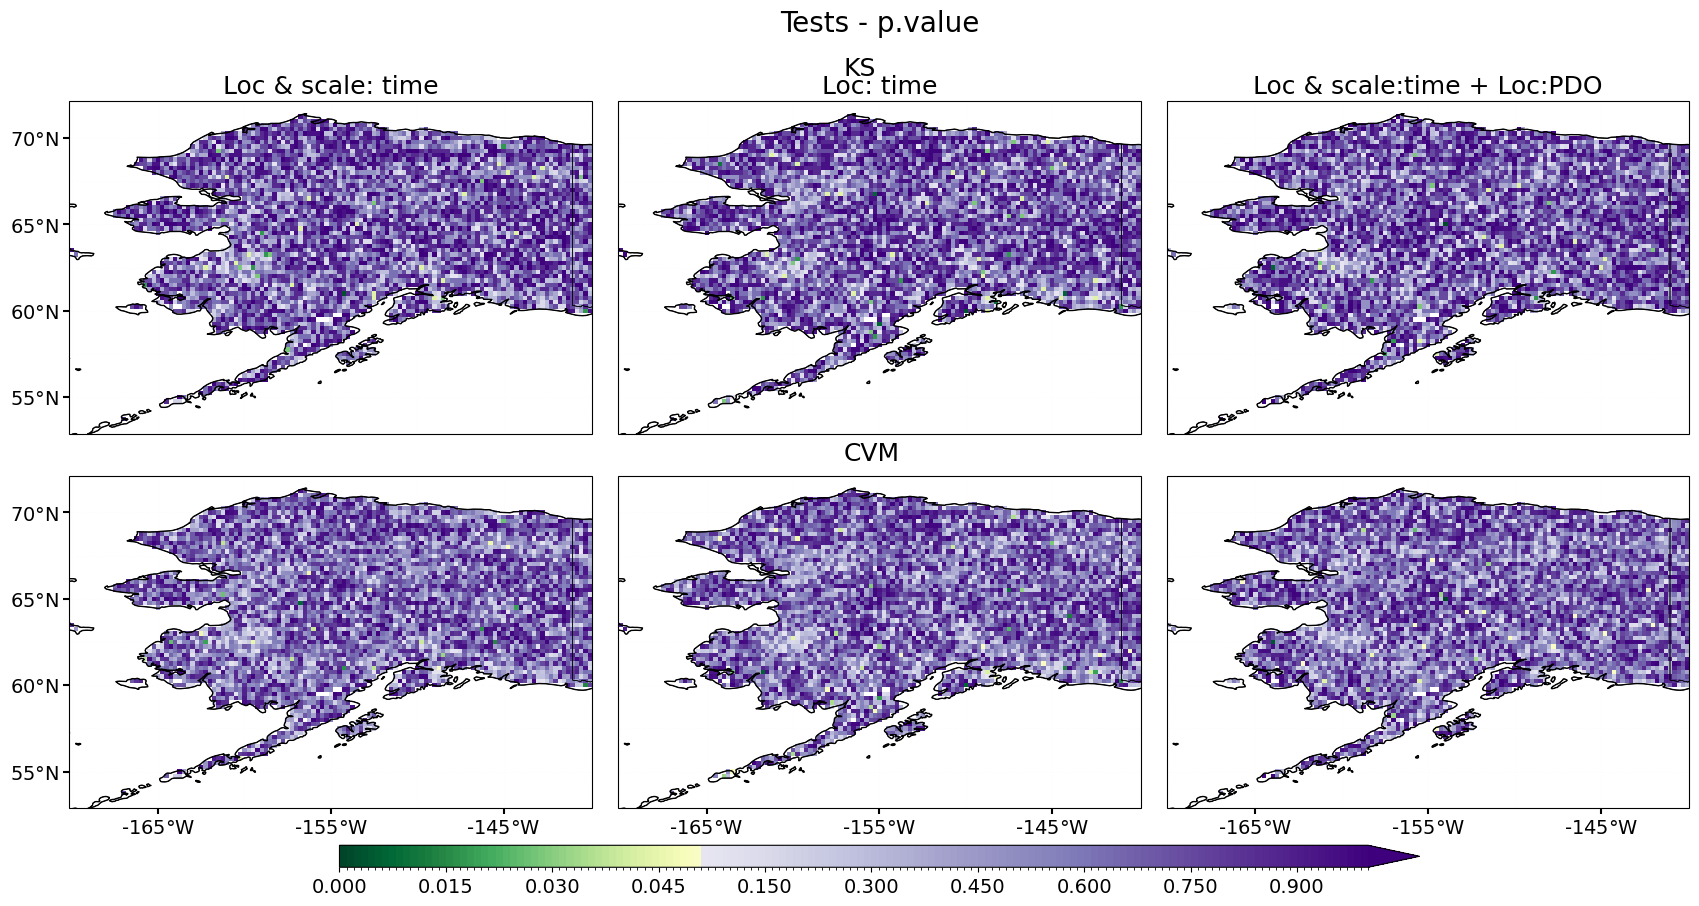

In [36]:
fig, ax = plt.subplots(nrows=2,ncols=len(Tloc),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.05, right=0.95,top=0.9,hspace=0.1,wspace=0.05)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = TKS_pvalue[ix].plot.pcolormesh(ax=ax[ix],cmap=pvalue_cmap,levels=pvalue_clevs,add_colorbar=False)
  cc = TCVM_pvalue[ix].plot.pcolormesh(ax=ax[ix+len(Tloc)],cmap=pvalue_cmap,levels=pvalue_clevs,add_colorbar=False)
fig.text(0.48,0.92,'KS',fontsize=18)
fig.text(0.48,0.57,'CVM',fontsize=18)
####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-len(Tloc):
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=len(Tloc)-1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,len(ax),len(Tloc)): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#

ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Tests - p.value',fontsize=20)  

Text(0.5, 0.98, 'Tests')

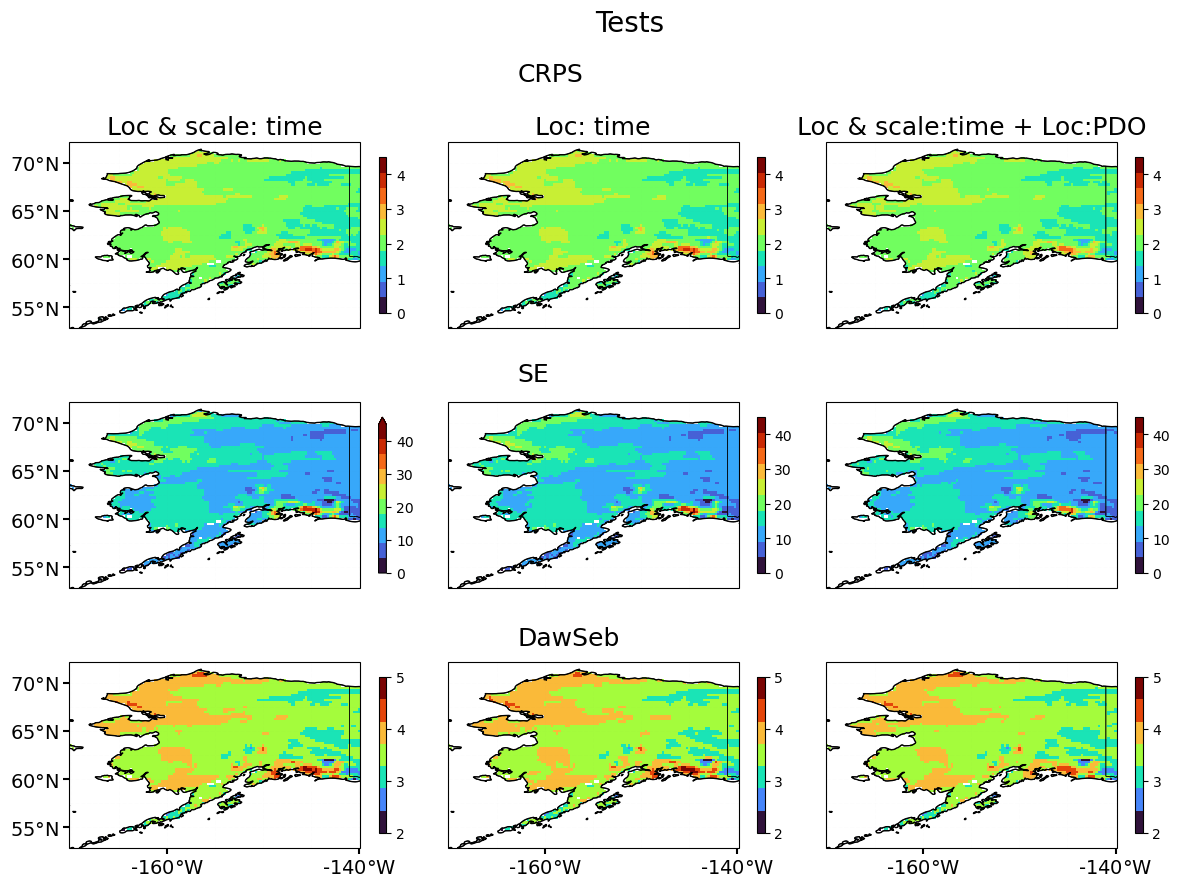

In [39]:
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=3,ncols=len(Tloc),figsize=(14,12),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=-0.,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  clevs = np.arange(0,5,0.5)
  cmap = plt.get_cmap('turbo',len(clevs)).copy()
  TCRPS[ix].mean('time').plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.6,'label':''})
  clevs = np.arange(0,50,5)
  cmap = plt.get_cmap('turbo',len(clevs)).copy()
  TSE[ix].mean('time').plot.pcolormesh(ax=ax[ix+len(Tloc)],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.6,'label':''})
  clevs = np.arange(2,5.5,0.5)
  cmap = plt.get_cmap('turbo',len(clevs)).copy()
  TDawSeb[ix].mean('time').plot.pcolormesh(ax=ax[ix+len(Tloc)*2],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.6,'label':''})
fig.text(0.42,0.92,'CRPS',fontsize=18)
fig.text(0.42,0.67,'SE',fontsize=18)
fig.text(0.42,0.45,'DawSeb',fontsize=18)
####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-len(Tloc):
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=len(Tloc)-1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,len(ax),len(Tloc)): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#

plt.suptitle(f'Tests',fontsize=20)  

In [48]:
xr.where(TKS_pvalue[0]<=0.05,1,0).sum()

<xarray.DataArray 'KS_pvalue' ()> Size: 8B
array(36)

In [49]:
nbKS = xr.DataArray([xr.where(TKS_pvalue[0]<0.05,1,0).sum(),xr.where(TKS_pvalue[1]<0.05,1,0).sum(),xr.where(TKS_pvalue[2]<0.05,1,0).sum()],dims=['models'])
nbCVM = xr.DataArray([xr.where(TCVM_pvalue[0]<0.05,1,0).sum(),xr.where(TCVM_pvalue[1]<0.05,1,0).sum(),xr.where(TCVM_pvalue[2]<0.05,1,0).sum()],dims=['models'])
meanCRPS = xr.DataArray([TCRPS[0].mean(),TCRPS[1].mean(),TCRPS[2].mean()],dims=['models'])
meanSE = xr.DataArray([TSE[0].mean(),TSE[1].mean(),TSE[2].mean()],dims=['models'])
meanDawSeb = xr.DataArray([TDawSeb[0].mean(),TDawSeb[1].mean(),TDawSeb[2].mean()],dims=['models'])

In [50]:
dsout = nbKS.to_dataset(name='KS')
dsout = dsout.merge({'CVM':nbCVM})
dsout = dsout.merge({'CRPS':meanCRPS})
dsout = dsout.merge({'SE':meanSE})
dsout = dsout.merge({'DawSeb':meanDawSeb})

In [51]:
dsout['models']=Tlabels
df = dsout.to_dataframe()
df = df.transpose()

In [55]:
df['diagnostic'] = ['KS pvalue <0.05 (#)','CVM pvalue <0.05 (#)','Mean CRPS','Mean SE','Mean DawSeb']

In [56]:
table = pd.pivot_table(df,  index=['diagnostic'])
table_style = table.style
styled_table = table_style.format('{:.2f}')
styled_table

models,Loc & scale: time,Loc & scale:time + Loc:PDO,Loc: time
diagnostic,,,
CVM pvalue <0.05 (#),23.00,13.00,30.00
KS pvalue <0.05 (#),36.00,26.00,46.00
Mean CRPS,2.08,2.06,2.08
Mean DawSeb,3.58,3.56,3.59
Mean SE,13.75,13.56,13.74


Comparison of models scores averaged over time and space. Tthe scoring rules are squared error (SE), Dawid-Sebastiani (DawSeb) and continuous ranked probability (CRPS). CVM pvalue <0.05 (#)/KS pvalue <0.05 (#) is the number of points where the pvalue of the CVM/KS test is under 0.05 (The distributions are significantly different.).  

In [25]:
import cmaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Define colors (names, hex codes, or RGB tuples)
B_colors =["xkcd:periwinkle","darkblue","blue","xkcd:electric blue","xkcd:lightish blue",\
           "xkcd:sky blue","xkcd:powder blue","aliceblue"]
# Create a smooth gradient colormap
Blues_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", B_colors)

# Define colors (names, hex codes, or RGB tuples)
R_colors = ["lightyellow","yellow","gold",  "darkorange","xkcd:blood orange",\
            "xkcd:red","darkred","xkcd:peachy pink"]
# Create a smooth gradient colormap
Reds_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", R_colors)
BR_map = ListedColormap(np.vstack((Blues_map.resampled(128)(np.linspace(0, 1, 128)),Reds_map.resampled(128)(np.linspace(0, 1, 128)))))

In [26]:
vq=[0.95,0.05]
proj=ccrs.PlateCarree()
Tquantile=['0.95','0.05']

Text(0.5, 0.98, 'Difference 2025-1941 Location parameter')

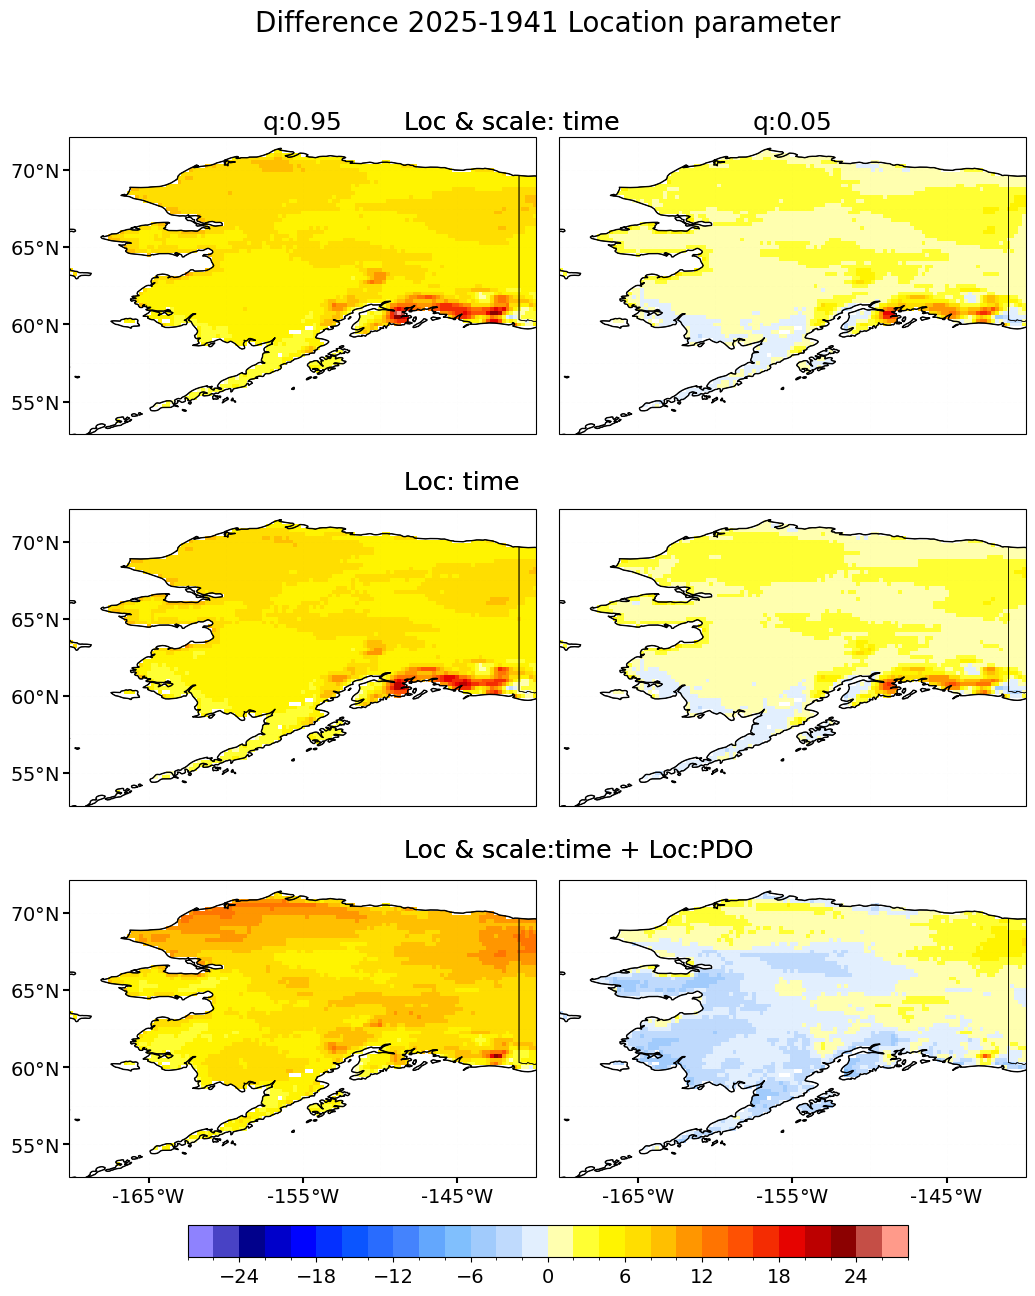

In [33]:
clevs = np.arange(-28,30,2)
cmap = BR_map

fig, ax = plt.subplots(nrows=len(Tloc),ncols=len(Tquantile),figsize=(12,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = Tlocdiff[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tlocdiff[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tlocdiff[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+4],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.38,0.905,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.38,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+2].set_title(f'',fontsize=18)   
  ax[ix+4].set_title(f'',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Scale parameter')

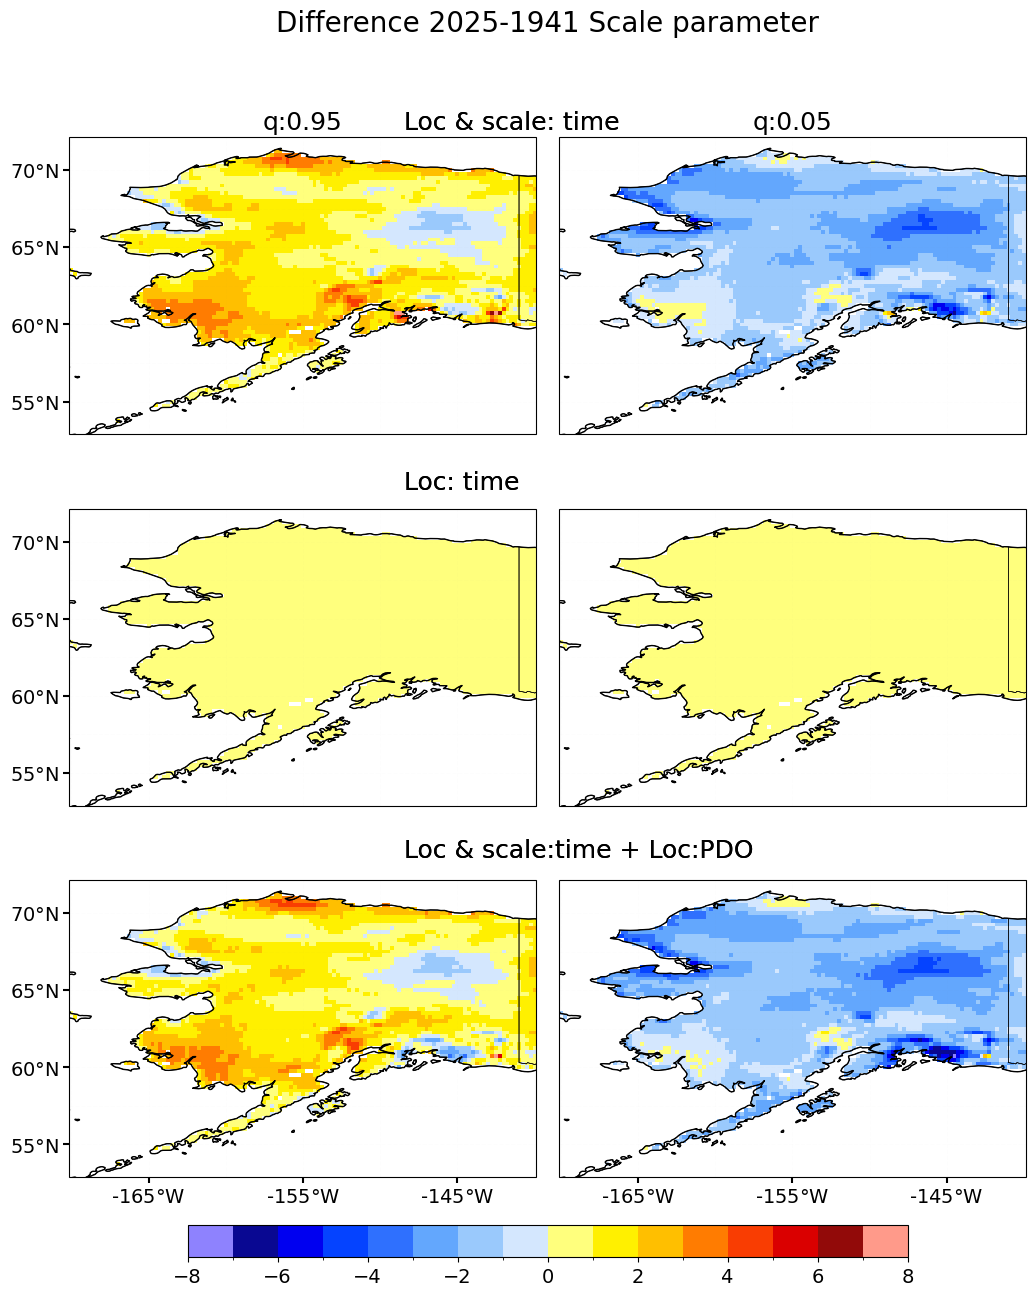

In [58]:
clevs = np.arange(-8,9,1)
cmap = BR_map

fig, ax = plt.subplots(nrows=len(Tloc),ncols=len(Tquantile),figsize=(12,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = Tscadiff[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tscadiff[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tscadiff[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+4],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.38,0.905,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.38,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+2].set_title(f'',fontsize=18)   
  ax[ix+4].set_title(f'',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Scale parameter',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Return Level 100 year')

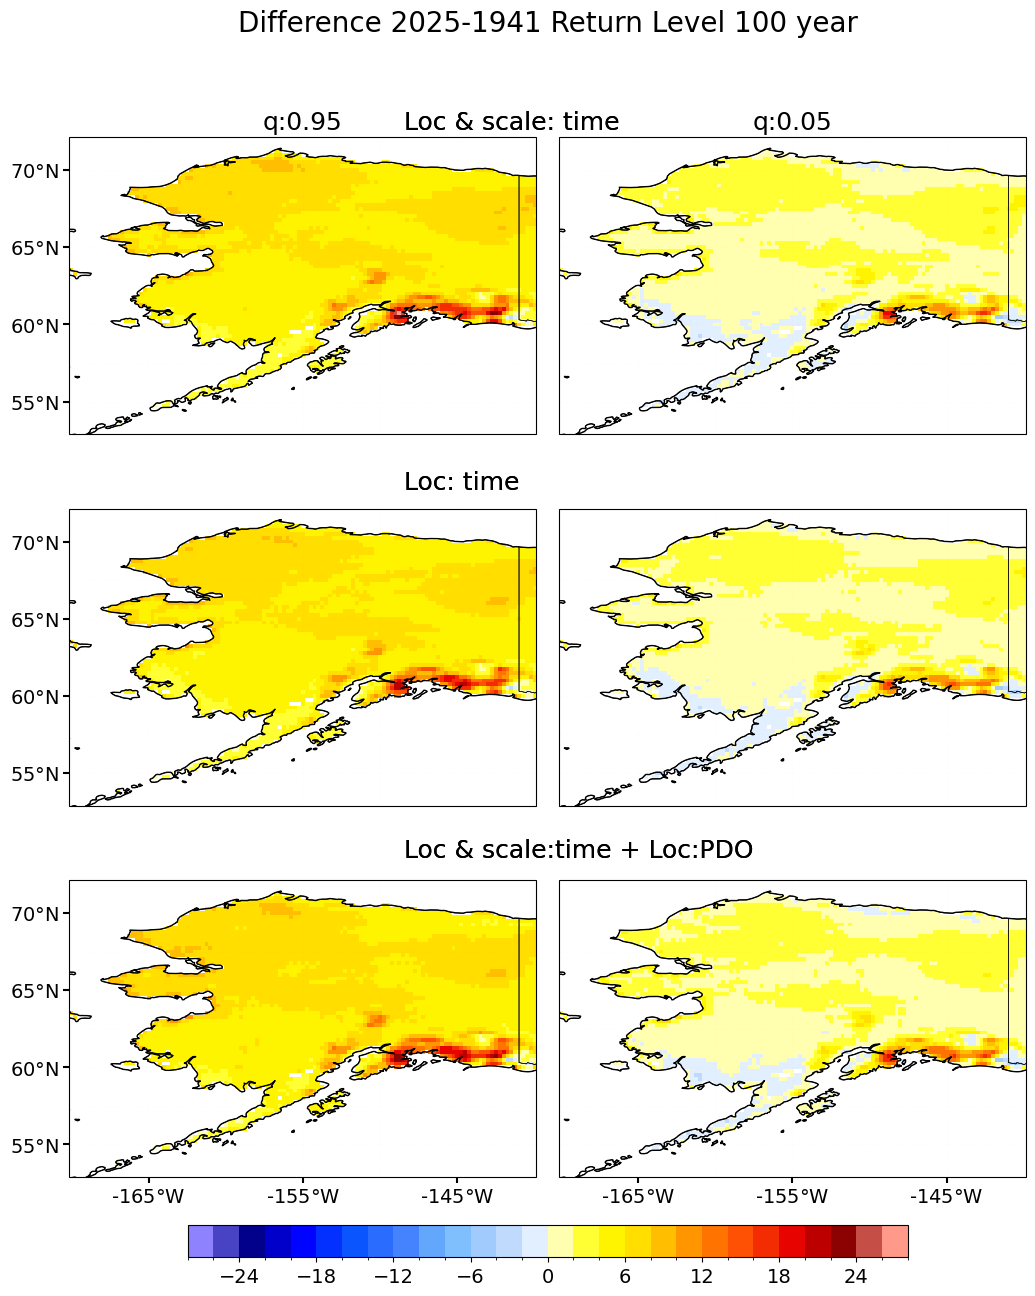

In [59]:
clevs = np.arange(-28,30,2)

fig, ax = plt.subplots(nrows=len(Tloc),ncols=len(Tquantile),figsize=(12,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = TRL[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = TRL[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = TRL[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+4],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.38,0.905,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.38,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+2].set_title(f'',fontsize=18)   
  ax[ix+4].set_title(f'',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Return Level 100 year',fontsize=20)  

In [61]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(1.,44,1)
clevsb=np.arange(0,1.1,1)
rr_clevs=np.concatenate((clevsb,clevsa))

##########
##########
rr_cmap = ListedColormap(np.vstack((Blues_map.resampled(128)(96),Reds_map.resampled(len(clevsa))(np.linspace(0, 1, len(clevsa))))))

Text(0.5, 0.98, 'Risk ratios 2025-1941')

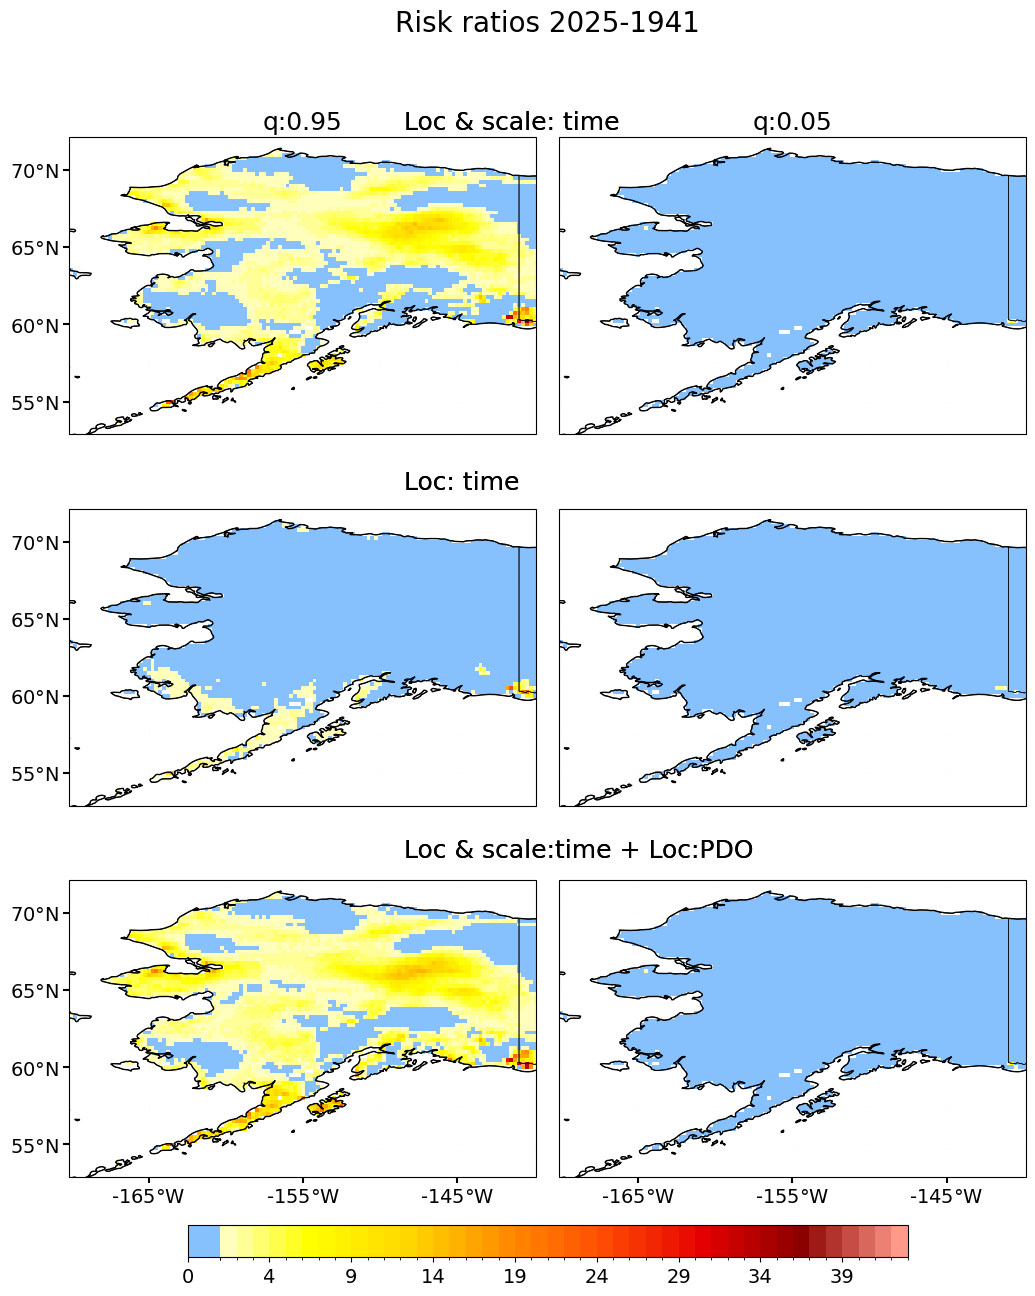

In [62]:


fig, ax = plt.subplots(nrows=len(Tloc),ncols=len(Tquantile),figsize=(12,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = TRR[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  cc = TRR[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  cc = TRR[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+4],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  fig.text(0.38,0.905,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.38,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+2].set_title(f'',fontsize=18)   
  ax[ix+4].set_title(f'',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)  
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Risk ratios {yeare}-{yearb}',fontsize=20)  


proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(14,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tpvalue)): 
  cc = Tpvalue[ix].plot.pcolormesh(ax=ax[ix],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)

for ix in range(0,len(Tpvalue)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tpvlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

plt.suptitle(f'p-value of N-S hypothesis',fontsize=20)  

# PLOT Return Level 100

Text(0.5, 0.98, 'Return Level 100year, Difference 2025 - 1941')

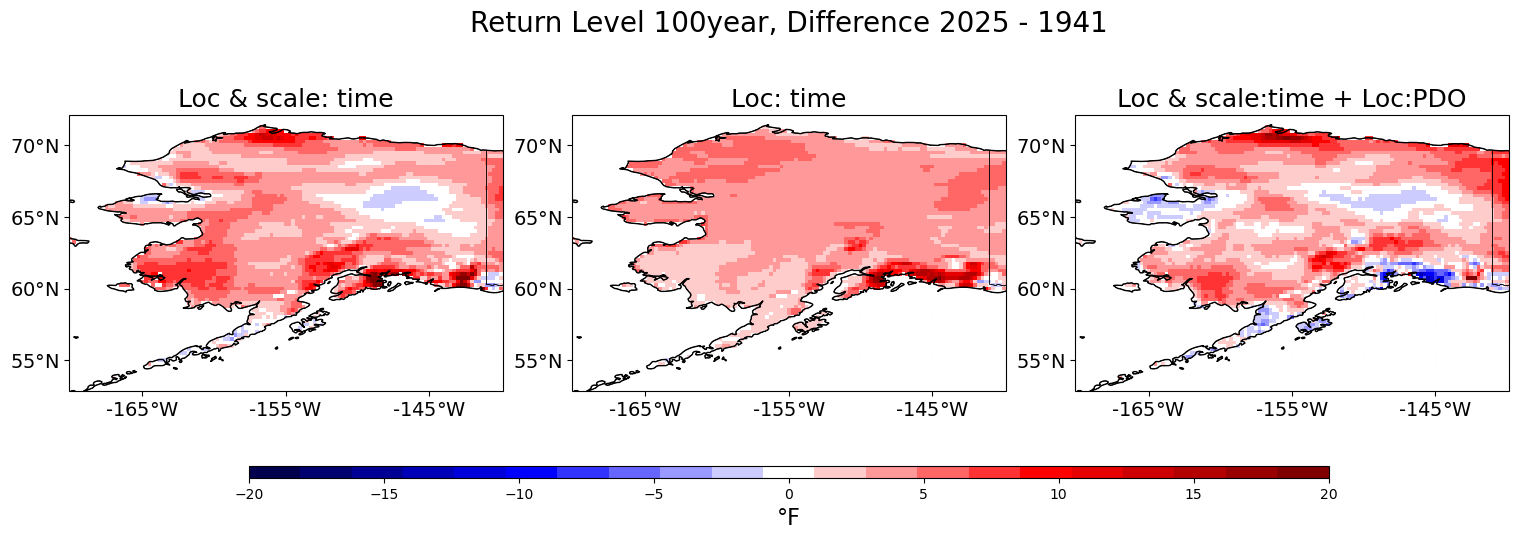

In [63]:
clevs = np.arange(-20,22,2)
cmap = plt.get_cmap('seismic',len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(18,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = (Trl100[ix].sel(time=yeare)-Trl100[ix].sel(time=yearb)).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)

####
for ix in range(0,len(Tloc)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.set_label(label=units,fontsize=16)
plt.suptitle(f'Return Level 100year, Difference {yeare} - {yearb}',fontsize=20)  

Text(0.5, 0.98, 'Return Level 100year: 1941')

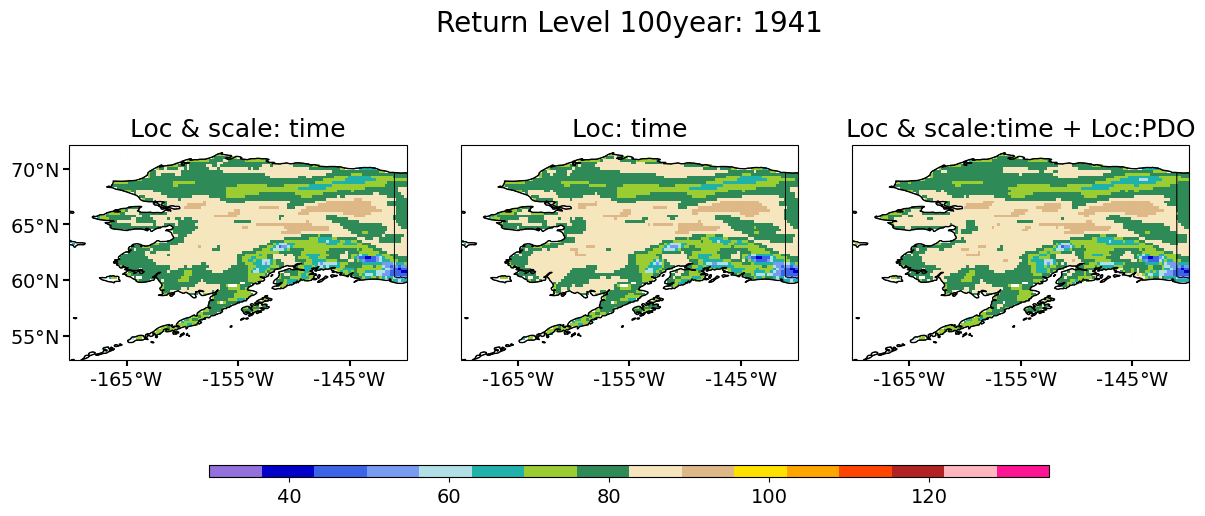

In [64]:
clevs = np.arange(30,140,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Trl100[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#
#
plt.suptitle(f'Return Level 100year: {yearb}',fontsize=20)  

Text(0.5, 0.98, 'Return Level 100year: 2025')

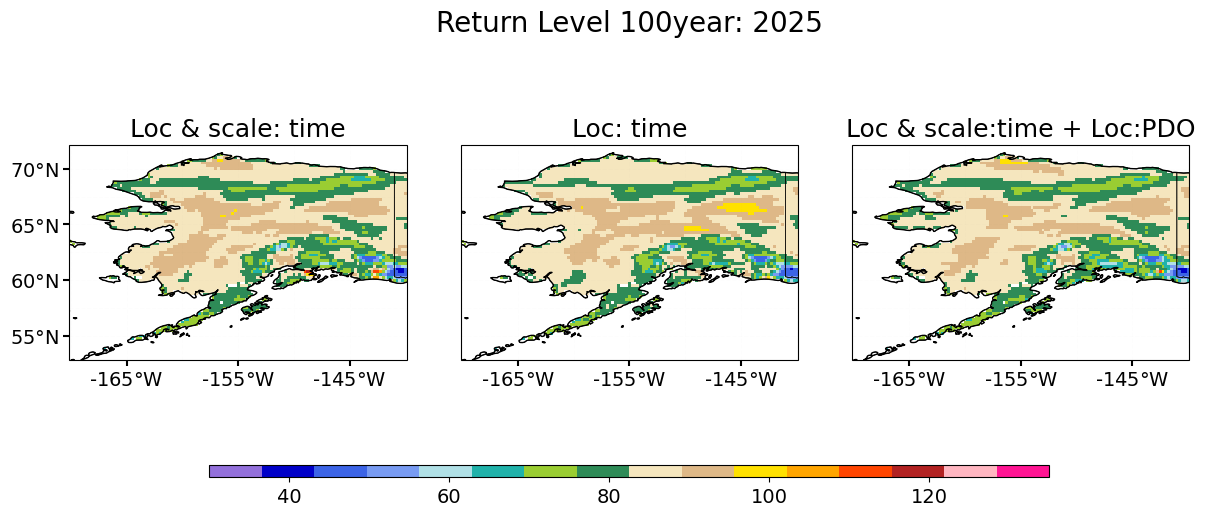

In [65]:
clevs = np.arange(30,140,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Trl100[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#
#
plt.suptitle(f'Return Level 100year: {yeare}',fontsize=20)  

Text(0.5, 0.98, 'Location parameter: 1941')

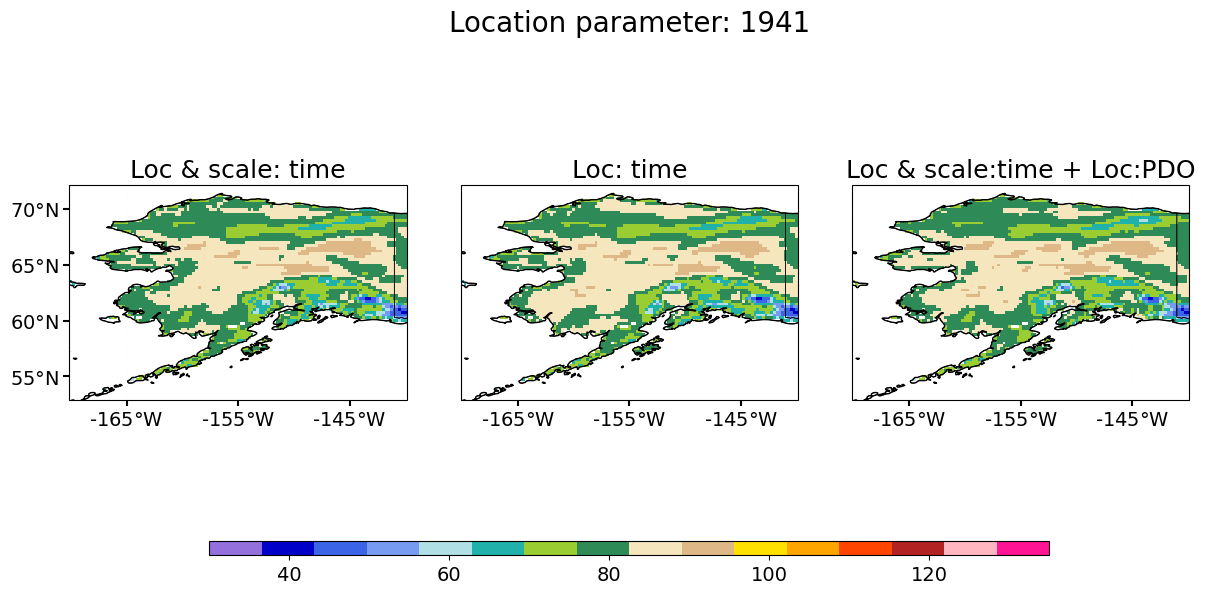

In [66]:
clevs = np.arange(30,140,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()
#clevs = np.arange(0,12,.5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

#
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Trl100[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

#
plt.suptitle(f'Location parameter: {yearb}',fontsize=20)  

Text(0.5, 0.98, 'Location parameter: 2025')

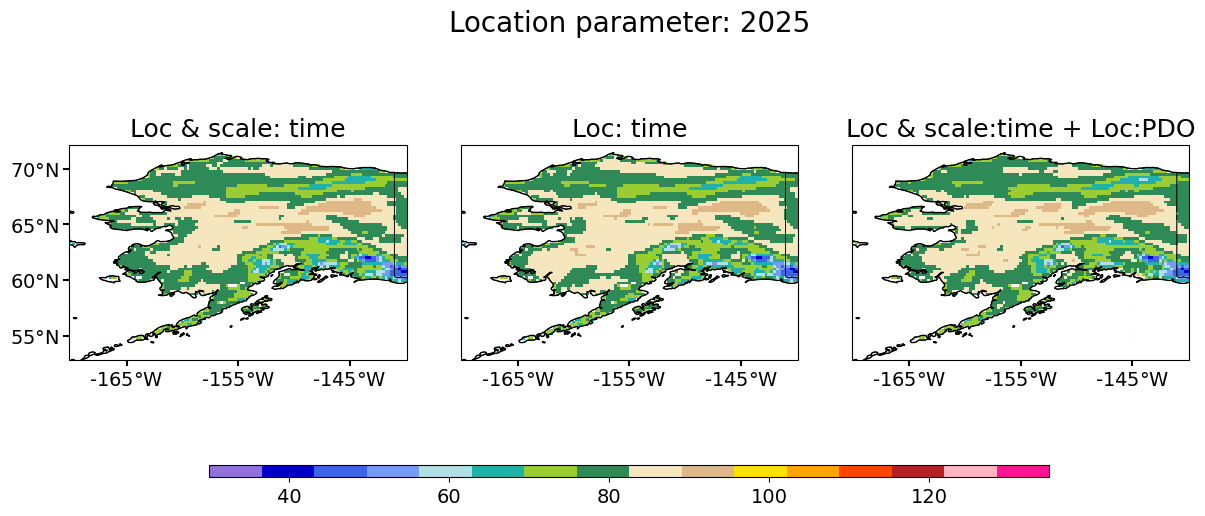

In [67]:
clevs = np.arange(30,140,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()
#clevs = np.arange(0,12,.5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

#
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Trl100[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

#
plt.suptitle(f'Location parameter: {yeare}',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter 1941')

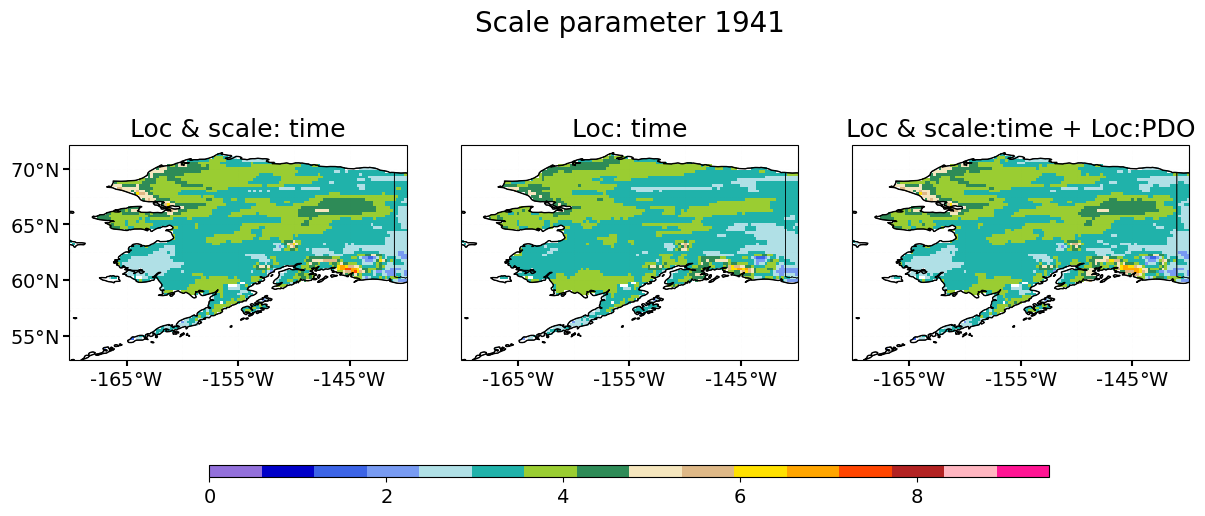

In [68]:
clevs = np.arange(0,10,.5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

#
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tscale[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

#
plt.suptitle(f'Scale parameter {yearb}',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter 2025')

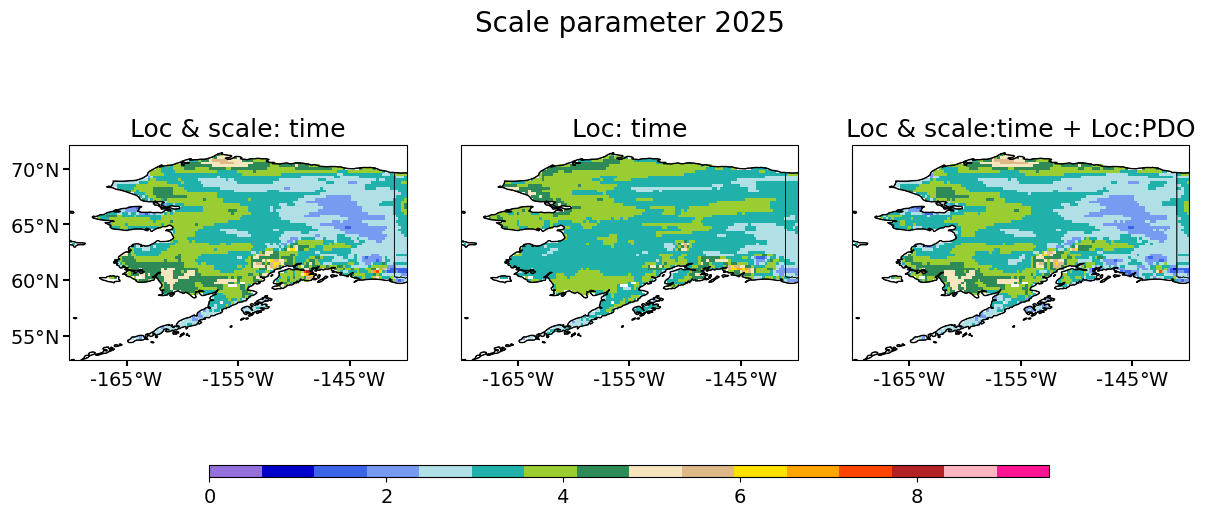

In [69]:
clevs = np.arange(0,10,.5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

#
fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tscale[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)

  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

#
plt.suptitle(f'Scale parameter {yeare}',fontsize=20)  

## Shape Parameter

Text(0.5, 0.98, 'Shape parameter, year=1941')

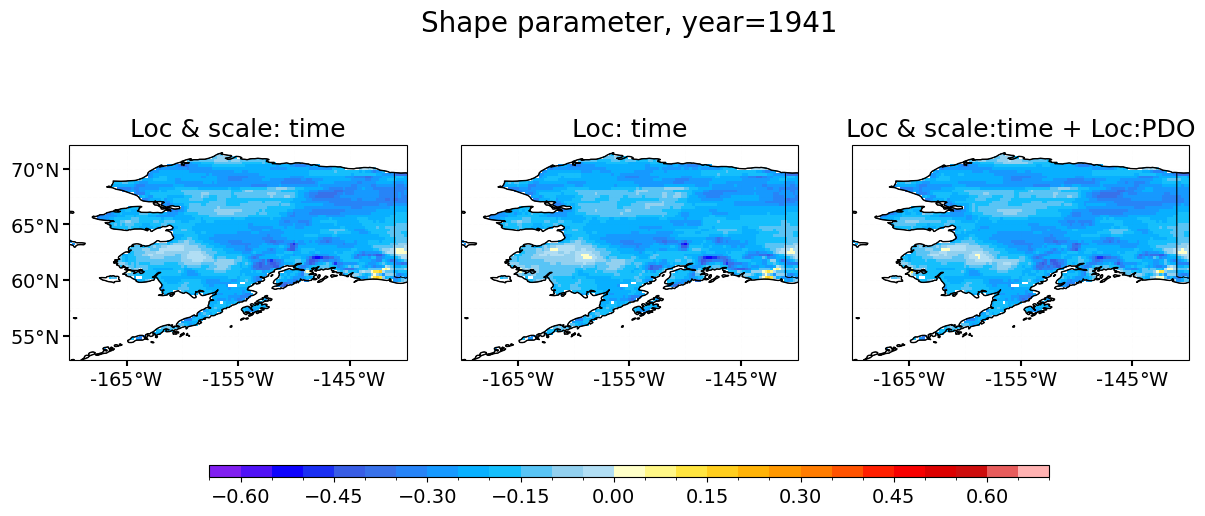

In [70]:
clevs = np.arange(-0.65,0.75,0.05)
cmap = plt.get_cmap(cmaps.ncl_default,len(clevs)).copy()

proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=len(Tloc),figsize=(14,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
ax = ax.flatten()
for ix in range(0,len(Tloc)): 
  cc = Tshape[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,levels=clevs,add_colorbar=False)

for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

plt.suptitle(f'Shape parameter, year={yearb}',fontsize=20)  